## 🔄 Dataset Merging Strategy – Combining Two Gesture Datasets

In this project, we aim to train a **more robust and realistic hand gesture recognition model** by combining two complementary datasets:

### 📂 1️⃣ LeapGestRecog – Hand Gesture Recognition Database
- ~20,000 infrared images
- Captured using a **Leap Motion sensor**
- 10 subjects (00 → 09)
- 10 gesture classes per subject
- Structured as:
``` 
leapGestRecog/
├── 00/
│   ├── 01_palm/
│   ├── 02_l/
│   ├── 03_fist/
│   └── ...
├── 01/
├── 02/
├── ...
└── 09/
```

---

### 📂 2️⃣ RYN-HGD 2.0 – Hand Gesture Dataset (Grayscale)
- ~31,000 grayscale images
- Captured using a **webcam**
- 256x256 resolution
- Organized directly by gesture class:
``` 
  Hand Gesture Dataset 2.O/
  ├── 01_palm/
  ├── 02_l/
  └── ...
``` 
This dataset represents **real-world webcam conditions**, closer to deployment scenarios.

---

## 🎯 Why Combine Them?

Training on a single dataset may lead to:
- Overfitting to one sensor type
- Poor generalization to real-world conditions

By combining both datasets, we:

✔ Increase total training samples (~51,000 images)  
✔ Improve model generalization  
✔ Make the model robust to different acquisition devices  
✔ Create a more realistic dataset for deployment (TinyML / Embedded AI)

---

## 🛠 What This Code Does

The merging script performs the following steps:

1. Iterates over each subject folder (00 → 09) in LeapGestRecog.
2. Iterates over each gesture class inside each subject.
3. Copies every image into the corresponding class folder inside:
   
   `/kaggle/working/merged_hand_gestures/`

4. Adds a **subject prefix** to each filename (e.g., `07_frame_07_09_0131.png`)  
   ➜ This prevents overwriting files with identical names.

Example:

Before:
leapGestRecog/07/09_c/frame_07_09_0131.png

After merging:

merged_hand_gestures/09_c/07_frame_07_09_0131.png

---

## 📊 Final Result

The final merged dataset structure becomes:
``` 
merged_hand_gestures/
├── 01_palm/
├── 02_l/
├── 03_fist/
├── ...
└── 10_down/
``` 
Each class folder now contains:
- Original RYN-HGD images
- Additional LeapGestRecog images

This combined dataset will be used to:
- Train the CNN model
- Improve generalization
- Prepare for TinyML deployment


In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [3]:
os.listdir('/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog')

['07', '05', '06', '02', '04', '00', '08', '09', '03', '01']

In [4]:
os.listdir('/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog/07')

['02_l',
 '04_fist_moved',
 '09_c',
 '10_down',
 '06_index',
 '08_palm_moved',
 '07_ok',
 '05_thumb',
 '01_palm',
 '03_fist']

In [5]:
import os
import shutil

# Read-only dataset paths
leap_dataset_path = '/kaggle/input/datasets/organizations/gti-upm/leapgestrecog/leapGestRecog'
ryn_dataset_path = '/kaggle/input/datasets/mrayyanshehzad/ryn-hgd-2-o-hand-gesture-dataset-grayscale/Hand Gesture Dataset 2.O - By M. RAYYAN SHEHZAD'
# Writable path to store merged dataset
merged_dataset_path = '/kaggle/working/merged_hand_gestures'
# Mapping from Leap folders to RYN class names
class_mapping = {
    '01_palm': '01_palm',
    '02_l': '02_l',
    '03_fist': '03_fist',
    '04_fist_moved': '04_fist_moved',
    '05_thumb': '05_thumb',
    '06_index': '06_index',
    '07_ok': '07_ok',
    '08_palm_moved': '08_palm_moved',
    '09_c': '09_c'
}

# First, copy RYN dataset into merged folder
for class_folder in os.listdir(ryn_dataset_path):
    src_class_path = os.path.join(ryn_dataset_path, class_folder)
    
    # Skip if not a folder
    if not os.path.isdir(src_class_path):
        continue
    
    tgt_class_path = os.path.join(merged_dataset_path, class_folder)
    os.makedirs(tgt_class_path, exist_ok=True)
    
    for img_file in os.listdir(src_class_path):
        src_img_path = os.path.join(src_class_path, img_file)
        
        # Only copy files
        if os.path.isfile(src_img_path):
            shutil.copy2(src_img_path, os.path.join(tgt_class_path, img_file))
# Second, copy Leap dataset into merged folder
# Loop over subjects (00,01,...09)
for subject_folder in os.listdir(leap_dataset_path):
    subject_path = os.path.join(leap_dataset_path, subject_folder)
    
    if not os.path.isdir(subject_path):
        continue
    
    # Loop over gesture classes inside subject
    for class_folder in os.listdir(subject_path):
        class_path = os.path.join(subject_path, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        # Target folder in merged dataset
        target_class_path = os.path.join(merged_dataset_path, class_folder)
        os.makedirs(target_class_path, exist_ok=True)
        
        # Copy each image
        for img_file in os.listdir(class_path):
            source_img_path = os.path.join(class_path, img_file)
            
            if os.path.isfile(source_img_path):
                # Add subject prefix to avoid overwriting
                new_filename = f"{subject_folder}_{img_file}"
                target_img_path = os.path.join(target_class_path, new_filename)
                
                shutil.copy2(source_img_path, target_img_path)
print(f"Datasets merged successfully into {merged_dataset_path}!")

Datasets merged successfully into /kaggle/working/merged_hand_gestures!


In [6]:
os.listdir('/kaggle/working/merged_hand_gestures/')

['05_thumb',
 '01_palm',
 '08_palm_moved',
 '06_index',
 '07_ok',
 '03_fist',
 '10_down',
 '09_c',
 '04_fist_moved',
 '02_l']

---

🚀 Next Steps:
- Verify total image count (~51,000 expected)
- Apply preprocessing (resize, normalization)
- Split into train/validation/test sets
- Train model
- Convert to TensorFlow Lite (TFLite)
- Deploy to embedded system (TinyML)

# Verify total image count (~51,000 expected)

In [7]:
def count_images(root_path):
    total = 0
    for root, dirs, files in os.walk(root_path):
        total += len(files)
    return total

print("Total images in merged dataset:",
      count_images('/kaggle/working/merged_hand_gestures'))

Total images in merged dataset: 51081


# Apply preprocessing (resize, normalization)

### 🔁 Summary Pipeline

### Resize all images

### Ensure grayscale (1 channel)

### Normalize pixel values

### Train / Validation / Test split

In [8]:
dataset_path = '/kaggle/working/merged_hand_gestures'

for d in os.listdir(dataset_path) :
    print(d)

05_thumb
01_palm
08_palm_moved
06_index
07_ok
03_fist
10_down
09_c
04_fist_moved
02_l


### Check number of images in each class : verify if classes are balanced

In [9]:
import os

dataset_path = '/kaggle/working/merged_hand_gestures/'
image_extensions = ('.jpg', '.jpeg', '.png')

for d in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, d)

    if os.path.isdir(folder_path):
        count = 0
        for f in os.listdir(folder_path):
            if f.lower().endswith(image_extensions):
                count += 1

        print(f"{d}: {count} images")

05_thumb: 5160 images
01_palm: 5158 images
08_palm_moved: 5186 images
06_index: 4956 images
07_ok: 4872 images
03_fist: 5119 images
10_down: 5177 images
09_c: 5159 images
04_fist_moved: 5142 images
02_l: 5152 images


# Reading images paths and assign labels

In [10]:
images = []
labels = []
for directory in os.listdir(dataset_path):
    for img in os.listdir(os.path.join(dataset_path, directory)):
      img_path = os.path.join(dataset_path, directory, img)
      images.append(img_path)
      labels.append(directory)
len(images),len(labels)

(51081, 51081)

In [11]:
# Get first 20 samples
sample_images = images[:20]
sample_labels = labels[:20]

# Method 1: Using zip (recommended)
for image, label in zip(sample_images, sample_labels):
    print(image)
    print(label)
    print("-" * 30)  # Separator for readability

/kaggle/working/merged_hand_gestures/05_thumb/03_frame_03_05_0068.png
05_thumb
------------------------------
/kaggle/working/merged_hand_gestures/05_thumb/05_thumb (1546).jpg
05_thumb
------------------------------
/kaggle/working/merged_hand_gestures/05_thumb/05_thumb (77).jpg
05_thumb
------------------------------
/kaggle/working/merged_hand_gestures/05_thumb/03_frame_03_05_0135.png
05_thumb
------------------------------
/kaggle/working/merged_hand_gestures/05_thumb/05_thumb (2147).jpg
05_thumb
------------------------------
/kaggle/working/merged_hand_gestures/05_thumb/05_thumb (559).jpg
05_thumb
------------------------------
/kaggle/working/merged_hand_gestures/05_thumb/05_thumb (2553).jpg
05_thumb
------------------------------
/kaggle/working/merged_hand_gestures/05_thumb/01_frame_01_05_0174.png
05_thumb
------------------------------
/kaggle/working/merged_hand_gestures/05_thumb/05_thumb (1316).jpg
05_thumb
------------------------------
/kaggle/working/merged_hand_gestures/

##### Note that 00_frame_00_08_0104.png match to class 8 (08)

In [12]:
images = np.array(images)
labels = np.array(labels)

### Now we will randomly distribute the dataset using randomly indexing 

In [13]:
arr_1d = np.array(["img00_1","img00_2", "img00_3","img00_9", "img04_8","img04_9", "img05_02","img05_05", "img07_12","img07_17"])
arr_2d = np.array(["00","00","00","00","04","04","05","05","07","07"])
# Create shuffled indices
shuffled_indices = np.random.permutation(len(arr_1d))
print(shuffled_indices)
# Reorder both arrays using the same indices
arr_1d_shffled = arr_1d[shuffled_indices]
arr_2d_shffled = arr_2d[shuffled_indices]
arr_1d_shffled,arr_2d_shffled

[7 8 0 1 5 6 9 3 4 2]


(array(['img05_05', 'img07_12', 'img00_1', 'img00_2', 'img04_9',
        'img05_02', 'img07_17', 'img00_9', 'img04_8', 'img00_3'],
       dtype='<U8'),
 array(['05', '07', '00', '00', '04', '05', '07', '00', '04', '00'],
       dtype='<U2'))

### Before randomly ditributing images :

In [14]:
images[:5],labels[:5],images[6000:6005],labels[6000:6005],images[13000:13005],labels[13000:13005],images[18000:18005],labels[18000:18005],images[22000:22005],labels[22000:22005]

(array(['/kaggle/working/merged_hand_gestures/05_thumb/03_frame_03_05_0068.png',
        '/kaggle/working/merged_hand_gestures/05_thumb/05_thumb (1546).jpg',
        '/kaggle/working/merged_hand_gestures/05_thumb/05_thumb (77).jpg',
        '/kaggle/working/merged_hand_gestures/05_thumb/03_frame_03_05_0135.png',
        '/kaggle/working/merged_hand_gestures/05_thumb/05_thumb (2147).jpg'],
       dtype='<U75'),
 array(['05_thumb', '05_thumb', '05_thumb', '05_thumb', '05_thumb'],
       dtype='<U13'),
 array(['/kaggle/working/merged_hand_gestures/01_palm/09_frame_09_01_0057.png',
        '/kaggle/working/merged_hand_gestures/01_palm/01_palm (3133).jpg',
        '/kaggle/working/merged_hand_gestures/01_palm/01_palm (45).jpg',
        '/kaggle/working/merged_hand_gestures/01_palm/01_palm (2654).jpg',
        '/kaggle/working/merged_hand_gestures/01_palm/03_frame_03_01_0081.png'],
       dtype='<U75'),
 array(['01_palm', '01_palm', '01_palm', '01_palm', '01_palm'],
       dtype='<U13'),
 ar

In [15]:
# Create shuffled indices
shuffled_indices = np.random.permutation(len(images))

# Reorder both arrays using the same indices
images_shuffled = images[shuffled_indices]
labels_shuffled = labels[shuffled_indices]

In [16]:
shuffled_indices[:20]

array([39356, 20511,  1401, 23009, 29224,  7199, 21617, 44098, 40372,
       36196, 22468,  7908, 29375,  3313,  3519, 42075,  9037, 47904,
       33882,  4862])

In [17]:
images_shuffled[:20]

array(['/kaggle/working/merged_hand_gestures/09_c/09_c (2102).jpg',
       '/kaggle/working/merged_hand_gestures/07_ok/07_ok (1361).jpg',
       '/kaggle/working/merged_hand_gestures/05_thumb/00_frame_00_05_0170.png',
       '/kaggle/working/merged_hand_gestures/07_ok/09_frame_09_07_0196.png',
       '/kaggle/working/merged_hand_gestures/03_fist/03_fist (2298).jpg',
       '/kaggle/working/merged_hand_gestures/01_palm/04_frame_04_01_0007.png',
       '/kaggle/working/merged_hand_gestures/07_ok/07_ok (289).jpg',
       '/kaggle/working/merged_hand_gestures/04_fist_moved/04_fist_moved (1828).jpg',
       '/kaggle/working/merged_hand_gestures/09_c/01_frame_01_09_0040.png',
       '/kaggle/working/merged_hand_gestures/09_c/09_c (1280).jpg',
       '/kaggle/working/merged_hand_gestures/07_ok/07_ok (827).jpg',
       '/kaggle/working/merged_hand_gestures/01_palm/01_palm (2920).jpg',
       '/kaggle/working/merged_hand_gestures/03_fist/03_fist (893).jpg',
       '/kaggle/working/merged_hand_g

### After randomly ditributing images :

In [18]:
images_shuffled[:5],labels_shuffled[:5],images_shuffled[6000:6005],labels_shuffled[6000:6005],images_shuffled[13000:13005],labels_shuffled[13000:13005],images_shuffled[18000:18005],labels_shuffled[18000:18005],images_shuffled[22000:22005],labels_shuffled[22000:22005]

(array(['/kaggle/working/merged_hand_gestures/09_c/09_c (2102).jpg',
        '/kaggle/working/merged_hand_gestures/07_ok/07_ok (1361).jpg',
        '/kaggle/working/merged_hand_gestures/05_thumb/00_frame_00_05_0170.png',
        '/kaggle/working/merged_hand_gestures/07_ok/09_frame_09_07_0196.png',
        '/kaggle/working/merged_hand_gestures/03_fist/03_fist (2298).jpg'],
       dtype='<U75'),
 array(['09_c', '07_ok', '05_thumb', '07_ok', '03_fist'], dtype='<U13'),
 array(['/kaggle/working/merged_hand_gestures/03_fist/03_fist (2174).jpg',
        '/kaggle/working/merged_hand_gestures/09_c/09_c (2263).jpg',
        '/kaggle/working/merged_hand_gestures/08_palm_moved/08_palm_moved (1752).jpg',
        '/kaggle/working/merged_hand_gestures/08_palm_moved/06_frame_06_08_0048.png',
        '/kaggle/working/merged_hand_gestures/10_down/10_down (458).jpg'],
       dtype='<U75'),
 array(['03_fist', '09_c', '08_palm_moved', '08_palm_moved', '10_down'],
       dtype='<U13'),
 array(['/kaggle/work

# Data Preprocessing

In [19]:
# Extract numeric prefix and convert to integer : for example extract 02 from 02_l
label_numbers = np.array([int(l.split('_')[0]) for l in labels_shuffled])
np.unique(label_numbers)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

### One-hot encoding
one-hot encoding means Instead of 2 you get: [0 0 1 0 0 0 0 0 0 0]

In [20]:
# One-hot encode (10 classes, assuming 00-09)
# Shift to 0-9
label_numbers = label_numbers - 1

num_classes = 10
labels_onehot = tf.keras.utils.to_categorical(label_numbers, num_classes=num_classes)

In [21]:
np.unique(np.argmax(labels_onehot, axis=1))  # should give 0-9

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [22]:
labels_onehot.shape

(51081, 10)

### Verify if images paths and labels match to each other :

In [23]:
labels_onehot[0],images_shuffled[0]

(array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
 np.str_('/kaggle/working/merged_hand_gestures/09_c/09_c (2102).jpg'))

In [24]:
labels_onehot[4],images_shuffled[4]

(array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 np.str_('/kaggle/working/merged_hand_gestures/03_fist/03_fist (2298).jpg'))

In [25]:
labels_onehot[19578],images_shuffled[19578]

(array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 np.str_('/kaggle/working/merged_hand_gestures/02_l/02_l (3149).jpg'))

In [26]:
labels_onehot[41854],images_shuffled[41854]

(array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]),
 np.str_('/kaggle/working/merged_hand_gestures/08_palm_moved/08_frame_08_08_0106.png'))

### Now each label like "01_palm" becomes [1,0,0,0,0,0,0,0,0,0]

### At tis moment we have images paths and their labels , we have to read the images , decode them , resize them , convert them to grascale images , normalize pixels values in order to get tensors with shape (64,64,1)

In [27]:
def load_and_preprocess(image_path, label):
    # Read and decode image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)  # Read as RGB first
    img.set_shape([None, None, 3])
    # Resize (maintains 3 channels)
    img = tf.image.resize(img, [64, 64])
    
    # Convert to grayscale (optional, reduces channels to 1)
    img = tf.image.rgb_to_grayscale(img)
    
    # Normalize to [0,1]
    img = img / 255.0
    
    return img, label


### Now we will Verify Preprocessing with two images , than move to apply preprocessing for all images

In [30]:
img_path1 = images_shuffled[0]
img_path2 = images_shuffled[1]
print(img_path1),print(img_path2)
img1 = tf.io.read_file(img_path1)
img2 = tf.io.read_file(img_path2)
img1 = tf.image.decode_image(img1, channels=3)
img2 = tf.image.decode_image(img2, channels=3)

/kaggle/working/merged_hand_gestures/09_c/09_c (2102).jpg
/kaggle/working/merged_hand_gestures/07_ok/07_ok (1361).jpg


In [31]:
img1.shape , img2.shape

(TensorShape([256, 256, 3]), TensorShape([256, 256, 3]))

In [33]:
img1,img2

(<tf.Tensor: shape=(256, 256, 3), dtype=uint8, numpy=
 array([[[148, 148, 148],
         [148, 148, 148],
         [146, 146, 146],
         ...,
         [146, 146, 146],
         [153, 153, 153],
         [145, 145, 145]],
 
        [[150, 150, 150],
         [213, 213, 213],
         [218, 218, 218],
         ...,
         [207, 207, 207],
         [207, 207, 207],
         [191, 191, 191]],
 
        [[146, 146, 146],
         [220, 220, 220],
         [218, 218, 218],
         ...,
         [211, 211, 211],
         [209, 209, 209],
         [187, 187, 187]],
 
        ...,
 
        [[154, 154, 154],
         [ 12,  12,  12],
         [ 12,  12,  12],
         ...,
         [184, 184, 184],
         [185, 185, 185],
         [174, 174, 174]],
 
        [[148, 148, 148],
         [ 17,  17,  17],
         [ 13,  13,  13],
         ...,
         [183, 183, 183],
         [184, 184, 184],
         [174, 174, 174]],
 
        [[153, 153, 153],
         [ 56,  56,  56],
         [ 62,

##### As we see , no necessary to the images being RGB 

In [34]:
img1_1 = tf.image.resize(img1, [64, 64])
img2_2 = tf.image.resize(img2, [64, 64])
img1_1 = img1_1 / 255.0
img2_2 = img2_2 / 255.0

### Convert to grayscale

In [35]:
img1_1.shape , img2_2.shape

(TensorShape([64, 64, 3]), TensorShape([64, 64, 3]))

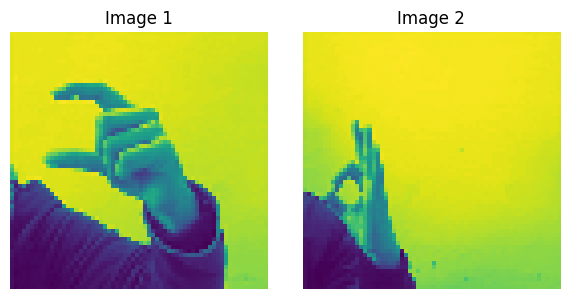

In [36]:
img1_1_1 = tf.image.rgb_to_grayscale(img1_1)
img2_2_2 = tf.image.rgb_to_grayscale(img2_2)

plt.figure(figsize=(6,3))   # control size of the whole figure

plt.subplot(1,2,1)          # 1 row, 2 columns, position 1
plt.imshow(img1_1_1)
plt.title("Image 1")
plt.axis("off")

plt.subplot(1,2,2)          # position 2
plt.imshow(img2_2_2)
plt.title("Image 2")
plt.axis("off")

plt.tight_layout()
plt.show()

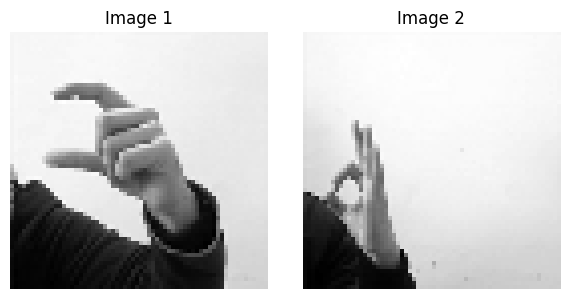

In [37]:
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img1_1_1.numpy().squeeze(), cmap="gray")
plt.title("Image 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2_2_2.numpy().squeeze(), cmap="gray")
plt.title("Image 2")
plt.axis("off")

plt.tight_layout()
plt.show()

In [38]:
img1_1_1.shape , img2_2_2.shape

(TensorShape([64, 64, 1]), TensorShape([64, 64, 1]))

### Create a TensorFlow Dataset from images and labels

In [39]:
dataset = tf.data.Dataset.from_tensor_slices((images_shuffled, labels_onehot))

In [40]:
# Take first 5 samples
for i, (image_path, label) in enumerate(dataset.take(5)):
    print(f"Sample {i}:")
    print(f"  Path: {image_path.numpy().decode('utf-8')}")
    print(f"  Label: {label.numpy()}")
    print("-" * 50)

Sample 0:
  Path: /kaggle/working/merged_hand_gestures/09_c/09_c (2102).jpg
  Label: [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
--------------------------------------------------
Sample 1:
  Path: /kaggle/working/merged_hand_gestures/07_ok/07_ok (1361).jpg
  Label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
--------------------------------------------------
Sample 2:
  Path: /kaggle/working/merged_hand_gestures/05_thumb/00_frame_00_05_0170.png
  Label: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
--------------------------------------------------
Sample 3:
  Path: /kaggle/working/merged_hand_gestures/07_ok/09_frame_09_07_0196.png
  Label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
--------------------------------------------------
Sample 4:
  Path: /kaggle/working/merged_hand_gestures/03_fist/03_fist (2298).jpg
  Label: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
--------------------------------------------------


In [41]:
# Count total elements
dataset_size = sum(1 for _ in dataset)
print(f"Total samples: {dataset_size}")

Total samples: 51081


In [42]:
dataset = dataset.map(load_and_preprocess)

# Split Data into Train/Val/Test

In [43]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Constants
BATCH_SIZE = 32
NUM_CLASSES = 10  # Based on your one-hot labels
IMG_SIZE = 64

# Calculate split sizes (70% train, 15% val, 15% test)
total_samples = 51081
train_size = int(0.7 * total_samples)  #35 756,7
val_size = int(0.15 * total_samples)   #7 662,15
test_size = total_samples - train_size - val_size  
train_size,val_size,test_size

(35756, 7662, 7663)

In [44]:
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size).take(val_size)
test_dataset = dataset.skip(train_size + val_size)
train_dataset_size = sum(1 for _ in train_dataset)
val_dataset_size = sum(1 for _ in val_dataset)
test_dataset_size = sum(1 for _ in test_dataset)
train_dataset_size , val_dataset_size ,test_dataset_size

(35756, 7662, 7663)

In [45]:
train_dataset = (train_dataset
                 .cache()
                 .shuffle(buffer_size=5000)
                 .batch(BATCH_SIZE)
                 .prefetch(tf.data.AUTOTUNE))

val_dataset = (val_dataset
               .cache()
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

test_dataset = (test_dataset
                .cache()
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))
# Verify the splits
print(f"\nTraining batches: {sum(1 for _ in train_dataset)}")
print(f"Validation batches: {sum(1 for _ in val_dataset)}")
print(f"Test batches: {sum(1 for _ in test_dataset)}")


Training batches: 1118
Validation batches: 240
Test batches: 240


### Note that every batch contain 32 images

In [46]:
# Inspect the first 5 BATCHES (each containing 32 images)
for batch_idx, (batch_images, batch_labels) in enumerate(train_dataset.take(5)):
    print(f"\nBatch {batch_idx + 1}:")
    print(f"  Batch images shape: {batch_images.shape}")  # Should be (32, 64, 64, 1)
    print(f"  Batch labels shape: {batch_labels.shape}")  # Should be (32, 10)
    
    # Look at first image in this batch
    first_image = batch_images[0]
    first_label = batch_labels[0]
    print(f"  First image shape: {first_image.shape}")  # Should be (64, 64, 1)
    print(f"  First label: {first_label.numpy()}")
    print(f"  First image min/max: {tf.reduce_min(first_image):.3f}, {tf.reduce_max(first_image):.3f}")


Batch 1:
  Batch images shape: (32, 64, 64, 1)
  Batch labels shape: (32, 10)
  First image shape: (64, 64, 1)
  First label: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  First image min/max: 0.012, 0.977

Batch 2:
  Batch images shape: (32, 64, 64, 1)
  Batch labels shape: (32, 10)
  First image shape: (64, 64, 1)
  First label: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
  First image min/max: 0.009, 0.938

Batch 3:
  Batch images shape: (32, 64, 64, 1)
  Batch labels shape: (32, 10)
  First image shape: (64, 64, 1)
  First label: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  First image min/max: 0.043, 0.906

Batch 4:
  Batch images shape: (32, 64, 64, 1)
  Batch labels shape: (32, 10)
  First image shape: (64, 64, 1)
  First label: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
  First image min/max: 0.018, 0.797

Batch 5:
  Batch images shape: (32, 64, 64, 1)
  Batch labels shape: (32, 10)
  First image shape: (64, 64, 1)
  First label: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
  First image min/max: 0.043, 0.894


### 2. Inspect First 3 Tensors from the first batch

In [47]:
# Inspect first 3 batches, and first 3 images from each
for batch_idx, (batch_images, batch_labels) in enumerate(test_dataset.take(1)):
    print(f"\n{'='*50}")
    print(f"BATCH {batch_idx + 1}")
    print(f"Batch shape: {batch_images.shape}")  # (32, 64, 64, 1)
    print(f"Batch labels shape: {batch_labels.shape}")  # (32, 10)
    print('='*50)
    
    # Inspect first 3 images in this batch
    for img_idx in range(min(3, len(batch_images))):
        image = batch_images[img_idx]
        label = batch_labels[img_idx]
        
        print(f"\n  Image {img_idx + 1} in Batch {batch_idx + 1}:")
        print(f"    Shape: {image.shape}")
        print(f"    Data type: {image.dtype}")
        print(f"    Value range: [{tf.reduce_min(image):.3f}, {tf.reduce_max(image):.3f}]")
        print(f"    Label (one-hot): {label.numpy()}")
        print(f"    Class: {tf.argmax(label).numpy()+1}")
        
        # Show a small sample of pixel values (top-left corner)
        print(f"    First 5x5 pixel values (top-left corner):")
        print(f"    {image[0:5, 0:5, 0].numpy()}")


BATCH 1
Batch shape: (32, 64, 64, 1)
Batch labels shape: (32, 10)

  Image 1 in Batch 1:
    Shape: (64, 64, 1)
    Data type: <dtype: 'float32'>
    Value range: [0.010, 0.977]
    Label (one-hot): [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    Class: 1
    First 5x5 pixel values (top-left corner):
    [[0.01960588 0.02009603 0.02156647 0.02597779 0.02328199]
 [0.01985096 0.02524257 0.02377213 0.02573272 0.02744824]
 [0.02450735 0.02156647 0.02058618 0.02818346 0.02818346]
 [0.02156647 0.02279184 0.02352706 0.0249975  0.02818346]
 [0.02058618 0.02083125 0.02426228 0.02769331 0.02891868]]

  Image 2 in Batch 1:
    Shape: (64, 64, 1)
    Data type: <dtype: 'float32'>
    Value range: [0.010, 0.846]
    Label (one-hot): [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
    Class: 10
    First 5x5 pixel values (top-left corner):
    [[0.01691007 0.01519456 0.01568471 0.01641993 0.01911574]
 [0.01764529 0.02426228 0.02230169 0.01641993 0.0213214 ]
 [0.01740022 0.01764529 0.01764529 0.01789037 0.01789037]
 [0.0188706

### Now we will visualize some images and verify their classes

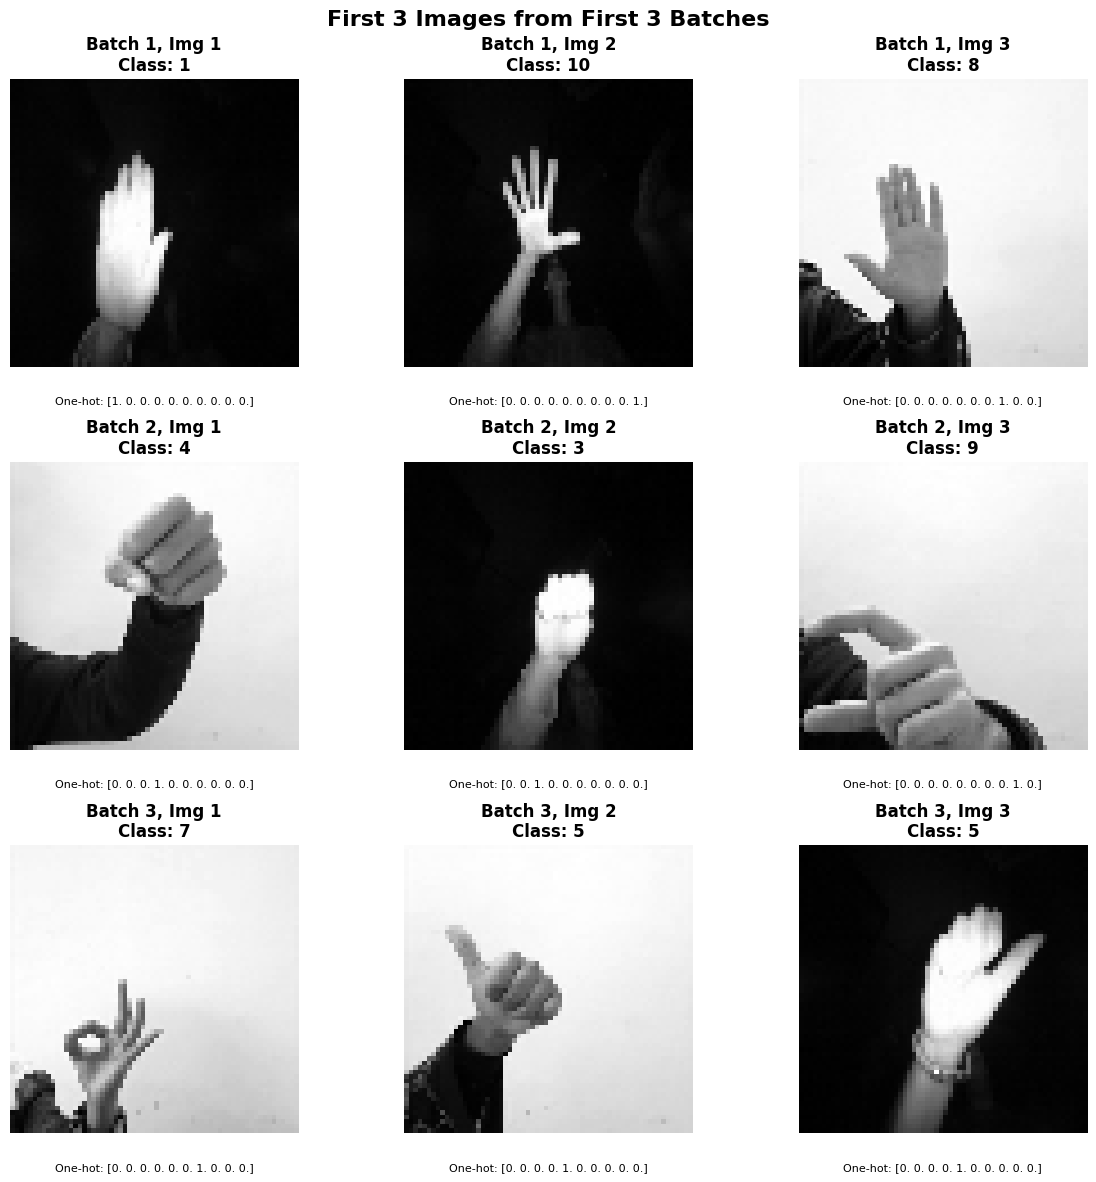

In [48]:
# Create a figure with 3 rows (batches) and 3 columns (images)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('First 3 Images from First 3 Batches', fontsize=16, fontweight='bold')

# Iterate through first 3 batches
for batch_idx, (batch_images, batch_labels) in enumerate(test_dataset.take(3)):
    # Take first 3 images from this batch
    for img_idx in range(3):
        img = batch_images[img_idx].numpy().squeeze()  # Remove channel dimension
        label = batch_labels[img_idx].numpy()
        class_id = np.argmax(label) + 1
        
        # Plot in the appropriate subplot
        ax = axes[batch_idx, img_idx]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Batch {batch_idx+1}, Img {img_idx+1}\nClass: {class_id}', 
                    fontsize=12, fontweight='bold')
        ax.axis('off')
        
        # Add a text box with the one-hot label
        label_text = f'One-hot: {label}'
        ax.text(0.5, -0.1, label_text, transform=ax.transAxes, 
               fontsize=8, ha='center', va='top')

plt.tight_layout()
plt.show()

# Build the CNN Model

In [49]:
from tensorflow.keras import layers, models

def create_tiny_cnn(input_shape=(64, 64, 1), num_classes=10):
    """
    Ultra-lightweight CNN for STM32F7 (target < 500KB)
    """
    model = models.Sequential([
        # First Convolutional Block - very small filters
        layers.Conv2D(8, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        
        # Second Convolutional Block
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Third Convolutional Block 
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),  # Instead of Flatten to reduce params
        
        # Dense layers - very small
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create model
model = create_tiny_cnn()
model.summary()



# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,274 (28.41 KB)

 Trainable params: 7,274 (28.41 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
import time

EPOCHS = 30

print("🚀 Starting training...")
print("="*60)

start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    verbose=1  # Show progress bars
)

training_time = time.time() - start_time

print(f"\n✅ Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

🚀 Starting training...
Epoch 1/30


I0000 00:00:1773158723.091328     123 service.cc:152] XLA service 0x7914f0002f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773158723.091381     123 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773158723.475273     123 cuda_dnn.cc:529] Loaded cuDNN version 91002


  55/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1000 - loss: 2.3029

I0000 00:00:1773158725.953743     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1118/1118 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.1298 - loss: 2.2646 - val_accuracy: 0.2826 - val_loss: 1.9496
Epoch 2/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2745 - loss: 1.8909 - val_accuracy: 0.3825 - val_loss: 1.6233
Epoch 3/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3618 - loss: 1.6524 - val_accuracy: 0.4946 - val_loss: 1.4247
Epoch 4/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4154 - loss: 1.5050 - val_accuracy: 0.5681 - val_loss: 1.2431
Epoch 5/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4492 - loss: 1.4234 - val_accuracy: 0.5980 - val_loss: 1.1416
Epoch 6/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4833 - loss: 1.3206 - val_accuracy: 0.6428 - val_loss: 1.0620
Epoch 7/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5145 - loss: 1.2519 - val_accuracy: 0.6635 - val_loss: 0.9842
Epoch 8/30
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5378 - loss: 1.1881 - val_accura

In [51]:
# Continue training for 10 more epochs
additional_epochs = 10
start_epoch = len(history.history['loss'])  # Should be 30

print(f"🚀 Continuing training for {additional_epochs} more epochs (epochs {start_epoch+1} to {start_epoch+additional_epochs})...")
print("="*60)

history2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    initial_epoch=start_epoch,
    epochs=start_epoch + additional_epochs,
    verbose=1
)

# Append new history to original history
for key in history.history.keys():
    history.history[key].extend(history2.history[key])

print(f"\n✅ Extended training completed. Total epochs now: {len(history.history['loss'])}")

🚀 Continuing training for 10 more epochs (epochs 31 to 40)...
Epoch 31/40
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7520 - loss: 0.6277 - val_accuracy: 0.8605 - val_loss: 0.3698
Epoch 32/40
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7586 - loss: 0.6203 - val_accuracy: 0.8487 - val_loss: 0.3889
Epoch 33/40
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7604 - loss: 0.6167 - val_accuracy: 0.8529 - val_loss: 0.3744
Epoch 34/40
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7661 - loss: 0.6010 - val_accuracy: 0.8594 - val_loss: 0.3623
Epoch 35/40
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7693 - loss: 0.5848 - val_accuracy: 0.8580 - val_loss: 0.3721
Epoch 36/40
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7742 - loss: 0.5763 - val_accuracy: 0.8481 - val_loss: 0.3790
Epoch 37/40
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7787 - loss: 0.5603 - val_accuracy: 0.8688 - val_loss: 0.3403
Epoch 38/40
1118/1118

In [52]:
# Continue training for 10 more epochs
additional_epochs = 10
start_epoch = len(history.history['loss'])  # Should be 40

print(f"🚀 Continuing training for {additional_epochs} more epochs (epochs {start_epoch+1} to {start_epoch+additional_epochs})...")
print("="*60)

history2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    initial_epoch=start_epoch,
    epochs=start_epoch + additional_epochs,
    verbose=1
)

# Append new history to original history
for key in history.history.keys():
    history.history[key].extend(history2.history[key])

print(f"\n✅ Extended training completed. Total epochs now: {len(history.history['loss'])}")

🚀 Continuing training for 10 more epochs (epochs 41 to 50)...
Epoch 41/50
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7882 - loss: 0.5303 - val_accuracy: 0.8841 - val_loss: 0.3020
Epoch 42/50
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7955 - loss: 0.5167 - val_accuracy: 0.8858 - val_loss: 0.2957
Epoch 43/50
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7964 - loss: 0.5087 - val_accuracy: 0.8953 - val_loss: 0.2823
Epoch 44/50
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8020 - loss: 0.5013 - val_accuracy: 0.8970 - val_loss: 0.2718
Epoch 45/50
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8054 - loss: 0.4921 - val_accuracy: 0.9034 - val_loss: 0.2631
Epoch 46/50
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8102 - loss: 0.4791 - val_accuracy: 0.9033 - val_loss: 0.2545
Epoch 47/50
1118/1118 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8067 - loss: 0.4783 - val_accuracy: 0.9012 - val_loss: 0.2581
Epoch 48/50
1118/1118

# Plot Training Curves

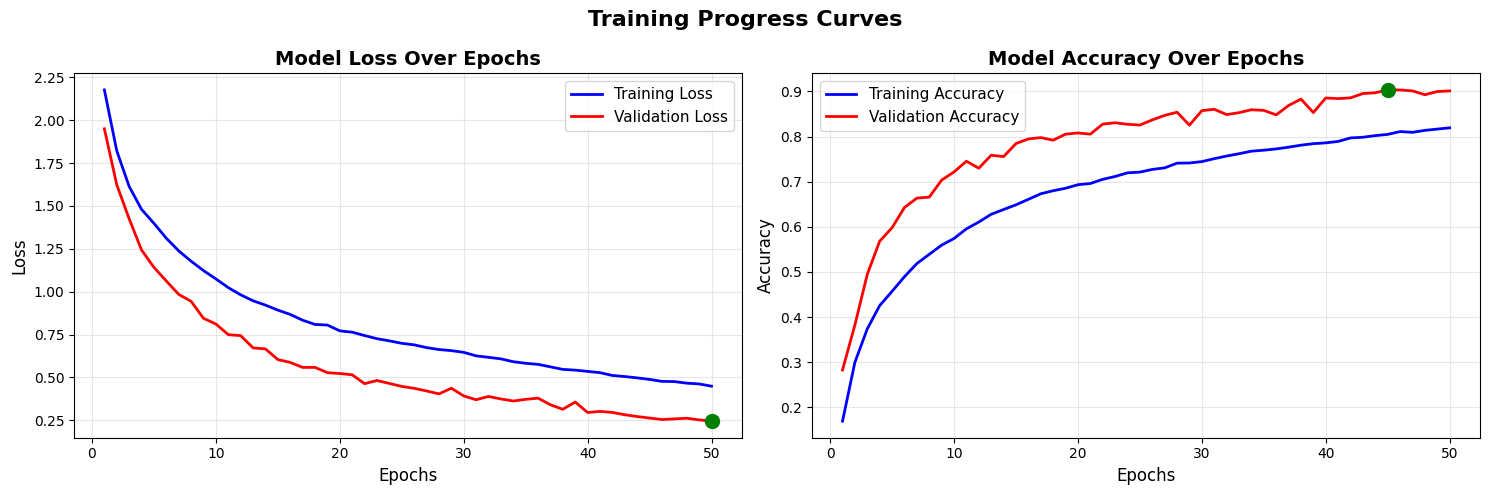


📊 TRAINING SUMMARY:
   Best Validation Loss: 0.2449 (Epoch 50)
   Best Validation Accuracy: 0.9034 (Epoch 45)
   Final Training Loss: 0.4489
   Final Validation Loss: 0.2449
   Final Training Accuracy: 0.8194
   Final Validation Accuracy: 0.9012


In [53]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_curves(history):
    """
    Plot training and validation loss & accuracy curves
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot 1: Loss
    axes[0].plot(epochs, history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0].plot(epochs, history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Find best epochs
    best_val_loss_epoch = np.argmin(history.history['val_loss']) + 1
    axes[0].scatter(best_val_loss_epoch, history.history['val_loss'][best_val_loss_epoch-1], 
                   color='green', s=100, zorder=5, label=f'Best Val Loss: Epoch {best_val_loss_epoch}')
    
    # Plot 2: Accuracy
    axes[1].plot(epochs, history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    axes[1].plot(epochs, history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    # Find best epochs
    best_val_acc_epoch = np.argmax(history.history['val_accuracy']) + 1
    axes[1].scatter(best_val_acc_epoch, history.history['val_accuracy'][best_val_acc_epoch-1], 
                   color='green', s=100, zorder=5, label=f'Best Val Acc: Epoch {best_val_acc_epoch}')
    
    plt.suptitle('Training Progress Curves', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n📊 TRAINING SUMMARY:")
    print(f"   Best Validation Loss: {min(history.history['val_loss']):.4f} (Epoch {best_val_loss_epoch})")
    print(f"   Best Validation Accuracy: {max(history.history['val_accuracy']):.4f} (Epoch {best_val_acc_epoch})")
    print(f"   Final Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"   Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print(f"   Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"   Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

# Plot curves
plot_training_curves(history)

# Step 5: Evaluate on Test Set

In [55]:
def evaluate_on_test(model, test_dataset, history):
    """
    Evaluate model on test set
    """
    print("\n" + "="*60)
    print("📈 TEST SET EVALUATION")
    print("="*60)
    
    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    
    # Get best validation metrics
    best_val_acc = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])
    best_epoch = np.argmax(history.history['val_accuracy']) + 1
    
    print(f"\n🏆 Best Validation Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")
    print(f"   Best Validation Loss: {best_val_loss:.4f}")
    
    # Compare with test
    print(f"\n📊 Comparison:")
    print(f"   Validation vs Test Accuracy: {best_val_acc:.4f} vs {test_accuracy:.4f}")
    print(f"   Validation vs Test Loss: {best_val_loss:.4f} vs {test_loss:.4f}")
    
    # Generalization gap
    acc_gap = abs(best_val_acc - test_accuracy)
    print(f"\n📊 Generalization Gap: {acc_gap:.4f} ({acc_gap*100:.2f}%)")
    
    if acc_gap < 0.02:
        print("✅ Excellent! Model generalizes very well!")
    elif acc_gap < 0.05:
        print("👍 Good generalization with minor gap")
    else:
        print("⚠️ Large gap - possible overfitting")
    
    return test_loss, test_accuracy

# Evaluate
test_loss, test_accuracy = evaluate_on_test(model, test_dataset, history)


📈 TEST SET EVALUATION
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9004 - loss: 0.2521

Test Loss: 0.2464
Test Accuracy: 0.8991 (89.91%)

🏆 Best Validation Accuracy: 0.9034 (Epoch 45)
   Best Validation Loss: 0.2449

📊 Comparison:
   Validation vs Test Accuracy: 0.9034 vs 0.8991
   Validation vs Test Loss: 0.2449 vs 0.2464

📊 Generalization Gap: 0.0043 (0.43%)
✅ Excellent! Model generalizes very well!


# Combined Plot (All in One Graph)

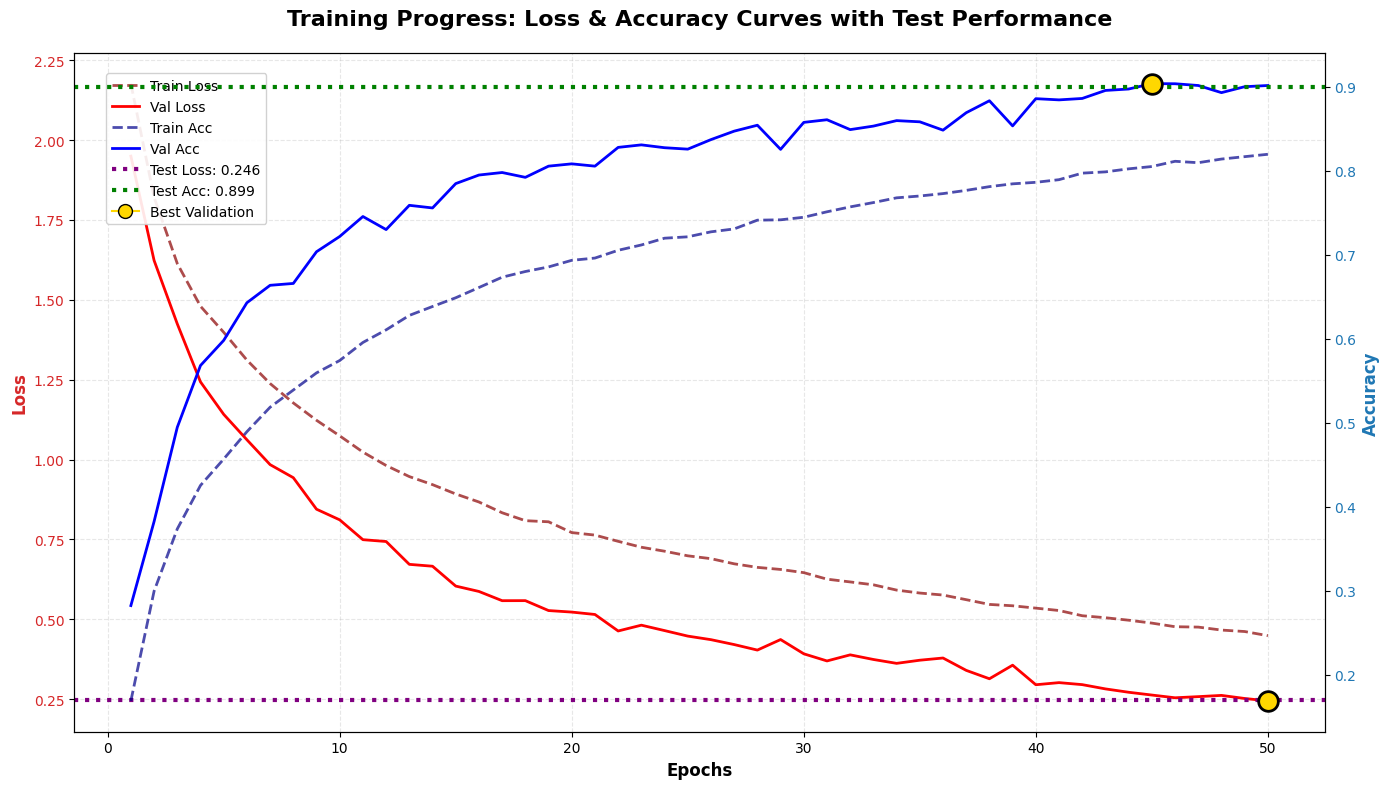

In [56]:
def plot_combined_metrics(history, test_loss, test_accuracy):
    """
    Plot all metrics in a single comprehensive graph
    """
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot loss on left y-axis
    color = 'tab:red'
    ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss', color=color, fontsize=12, fontweight='bold')
    line1 = ax1.plot(epochs, history.history['loss'], '--', color='darkred', 
                     label='Train Loss', linewidth=2, alpha=0.7)
    line2 = ax1.plot(epochs, history.history['val_loss'], color='red', 
                     label='Val Loss', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Add test loss as horizontal line
    ax1.axhline(y=test_loss, color='purple', linestyle=':', 
                linewidth=3, label=f'Test Loss: {test_loss:.3f}')
    
    # Plot accuracy on right y-axis
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Accuracy', color=color, fontsize=12, fontweight='bold')
    line3 = ax2.plot(epochs, history.history['accuracy'], '--', color='darkblue', 
                     label='Train Acc', linewidth=2, alpha=0.7)
    line4 = ax2.plot(epochs, history.history['val_accuracy'], color='blue', 
                     label='Val Acc', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Add test accuracy as horizontal line
    ax2.axhline(y=test_accuracy, color='green', linestyle=':', 
                linewidth=3, label=f'Test Acc: {test_accuracy:.3f}')
    
    # Mark best validation points
    best_val_acc_epoch = np.argmax(history.history['val_accuracy']) + 1
    best_val_acc = max(history.history['val_accuracy'])
    ax2.scatter(best_val_acc_epoch, best_val_acc, color='gold', s=200, 
                zorder=5, edgecolors='black', linewidth=2, 
                label=f'Best Val Acc: {best_val_acc:.3f}')
    
    best_val_loss_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = min(history.history['val_loss'])
    ax1.scatter(best_val_loss_epoch, best_val_loss, color='gold', s=200, 
                zorder=5, edgecolors='black', linewidth=2,
                label=f'Best Val Loss: {best_val_loss:.3f}')
    
    # Combine legends
    lines = line1 + line2 + line3 + line4
    labels = [l.get_label() for l in lines]
    
    # Add custom legend entries for test lines
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='purple', linestyle=':', linewidth=3),
                    Line2D([0], [0], color='green', linestyle=':', linewidth=3),
                    Line2D([0], [0], marker='o', color='gold', markersize=10, 
                          markerfacecolor='gold', markeredgecolor='black')]
    custom_labels = [f'Test Loss: {test_loss:.3f}', 
                     f'Test Acc: {test_accuracy:.3f}',
                     'Best Validation']
    
    all_lines = lines + custom_lines
    all_labels = labels + custom_labels
    
    # Add legend
    ax1.legend(all_lines, all_labels, loc='upper left', fontsize=10, 
               bbox_to_anchor=(0.02, 0.98), framealpha=0.9)
    
    plt.title('Training Progress: Loss & Accuracy Curves with Test Performance', 
              fontsize=16, fontweight='bold', pad=20)
    fig.tight_layout()
    plt.show()

# Plot combined metrics
plot_combined_metrics(history, test_loss, test_accuracy)

# Confusion Matrix for Test Set



CONFUSION MATRIX - TEST SET


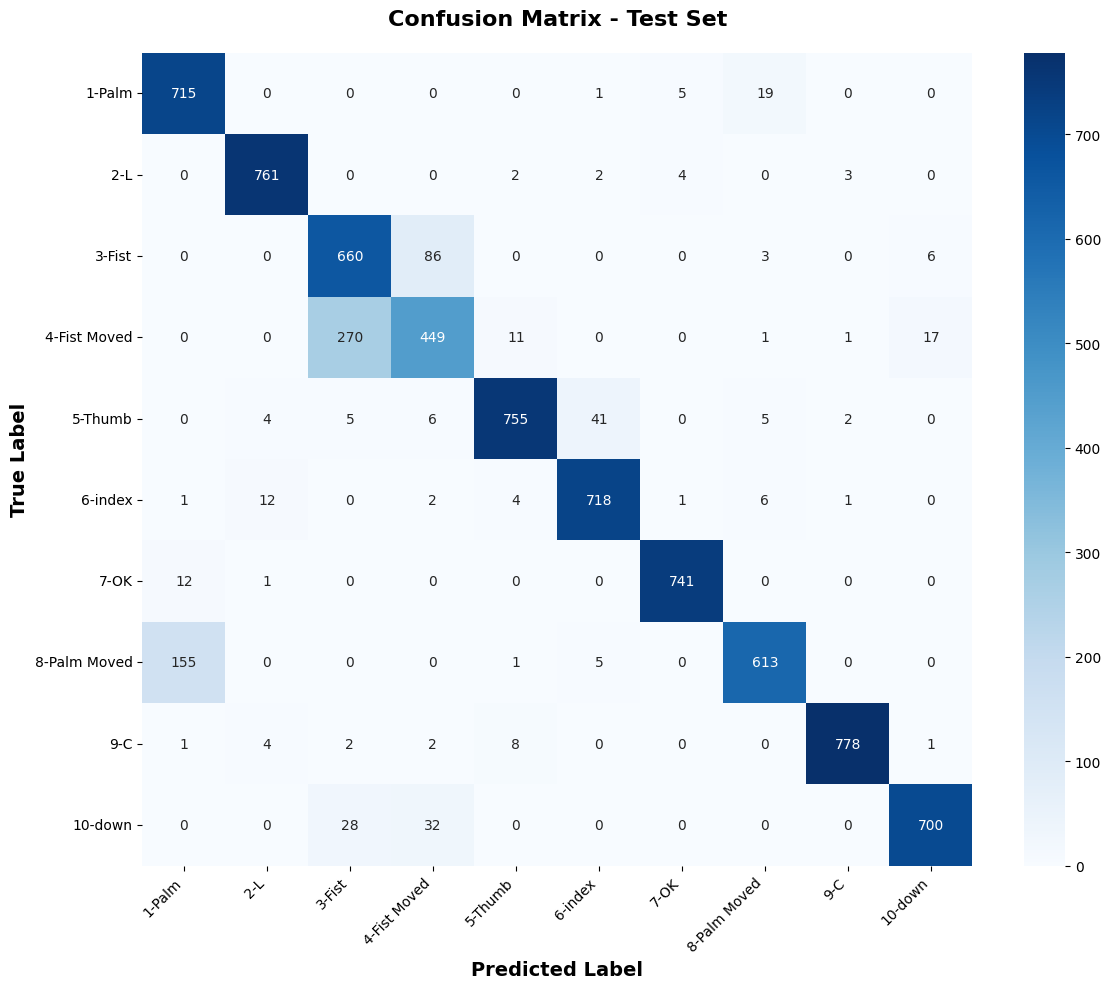


📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      1-Palm       0.81      0.97      0.88       740
         2-L       0.97      0.99      0.98       772
      3-Fist       0.68      0.87      0.77       755
4-Fist Moved       0.78      0.60      0.68       749
     5-Thumb       0.97      0.92      0.94       818
     6-index       0.94      0.96      0.95       745
        7-OK       0.99      0.98      0.98       754
8-Palm Moved       0.95      0.79      0.86       774
         9-C       0.99      0.98      0.98       796
     10-down       0.97      0.92      0.94       760

    accuracy                           0.90      7663
   macro avg       0.90      0.90      0.90      7663
weighted avg       0.91      0.90      0.90      7663


 PER-CLASS ACCURACY:
1-Palm              : 96.62% (715/740)
2-L                 : 98.58% (761/772)
3-Fist              : 87.42% (660/755)
4-Fist Moved        : 59.95% (449/749)
5-Thumb             : 92.30% (755/818

In [57]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

def plot_confusion_matrix(model, test_dataset):
    """
    Plot confusion matrix for test set predictions
    """
    # Define class names (adjust according to your actual classes)
    class_names = ['1-Palm', '2-L', '3-Fist', '4-Fist Moved', 
                   '5-Thumb', '6-index', '7-OK', '8-Palm Moved', '9-C','10-down']
    
    print("\n" + "="*60)
    print("CONFUSION MATRIX - TEST SET")
    print("="*60)
    
    # Get predictions
    y_true = []
    y_pred = []
    
    # Iterate through test dataset
    for images, labels in test_dataset:
        predictions = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Calculate accuracy per class
    class_accuracy = cm.diagonal() / cm.sum(axis=1)
    
    # Plot
    plt.figure(figsize=(12, 10))
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'size': 10})
    
    plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Print classification report
    print("\n📋 CLASSIFICATION REPORT:")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Print per-class accuracy
    print("\n PER-CLASS ACCURACY:")
    print("="*60)
    for i, name in enumerate(class_names):
        print(f"{name:20s}: {class_accuracy[i]:.2%} ({cm[i,i]}/{cm.sum(axis=1)[i]})")
    
    # Overall accuracy
    overall_acc = np.sum(cm.diagonal()) / np.sum(cm)
    print(f"\n Overall Test Accuracy: {overall_acc:.2%}")
    
    return cm, y_true, y_pred

# Plot confusion matrix
cm, y_true, y_pred = plot_confusion_matrix(model, test_dataset)

# ⚠️ IMPORTANT NOTE ABOUT THE DATASET AND MODEL PREDICTIONS ⚠️

**The issues of the model are NOT related to the model architecture or the training process.**  

The main reason for misclassifications comes from the **RYN-HGD 2.0 dataset**, where some classes are **almost identical**:  

- **Class 1 – Palm** and **Class 8 – Palm-moved** are extremely similar.  
  - You can visually compare the images in each class and notice they look nearly the same.  
  - As a result, the model predicts **Palm** while the true label is **Palm-moved** **155 times**.  
  - In contrast, in the **LeapGestRecog dataset**, the images of these two classes are more distinct.  

- **Similarly, Class 3 – Fist** and **Class 4 – Fist-moved** have the same issue.

  - the model predicts **Fist** while the true label is **Fist-moved** **270 times**.  
  - The model often confuses these classes because their visual differences are minimal in RYN-HGD 2.0.  

**Conclusion:** Misclassifications are mainly due to dataset labeling and class similarity, **not the CNN model or the training procedure.**

# Save Model for STM32 Deployment

In [58]:
# Convert to TFLite for STM32
def prepare_for_stm32(model, test_dataset):
    """
    Convert model to TFLite format for STM32 deploymentA
    """
    print("\n" + "="*60)
    print("🔧 PREPARING MODEL FOR STM32 DEPLOYMENT")
    print("="*60)
    
    # Representative dataset for quantization
    def representative_dataset():
        for images, _ in test_dataset.take(100):
            yield [images]
    
    # Convert with optimization
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    
    # Convert model
    tflite_model = converter.convert()
    
    # Save model
    with open('stm32_gesture_model.tflite', 'wb') as f:
        f.write(tflite_model)
    
    # Check size
    size_kb = len(tflite_model) / 1024
    print(f"📦 TFLite model size: {size_kb:.2f} KB")
    print(f"✅ Model ready for STM32F7!")
    
    # Generate C header
    def generate_c_header(tflite_model, filename='model_data.h'):
        with open(filename, 'w') as f:
            f.write('#ifndef MODEL_DATA_H\n')
            f.write('#define MODEL_DATA_H\n\n')
            f.write('#include <stdint.h>\n\n')
            f.write('const unsigned char model_tflite[] = {\n    ')
            
            # Write model data in hex format
            for i, byte in enumerate(tflite_model):
                f.write(f'0x{byte:02x}, ')
                if (i + 1) % 12 == 0 and i != len(tflite_model) - 1:
                    f.write('\n    ')
            
            f.write('\n};\n\n')
            f.write(f'const unsigned int model_tflite_len = {len(tflite_model)};\n\n')
            f.write('#endif // MODEL_DATA_H\n')
    
    generate_c_header(tflite_model)
    print("📄 C header file 'model_data.h' generated for STM32")
    
    return tflite_model

# Prepare for STM32
tflite_model = prepare_for_stm32(model, test_dataset)


🔧 PREPARING MODEL FOR STM32 DEPLOYMENT
INFO:tensorflow:Assets written to: /tmp/tmp3cahuuz4/assets


INFO:tensorflow:Assets written to: /tmp/tmp3cahuuz4/assets


Saved artifact at '/tmp/tmp3cahuuz4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133133671827408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133672044048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133672045008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133672043664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133672046544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133672043472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133672045200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133672046352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133672046736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133133672046928: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1773159338.479921      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1773159338.479955      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1773159338.488139      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


📦 TFLite model size: 13.98 KB
✅ Model ready for STM32F7!
📄 C header file 'model_data.h' generated for STM32


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


# Purpose of generating a C header

STM32 microcontrollers don't read .tflite files from disk like a PC. Instead, the model needs to be embedded directly into the microcontroller's program memory as a C array. That's what this C header does: it turns the binary .tflite file into a const unsigned char array that can be compiled with STM32 firmware.

In [60]:
# Load the TFLite model
#read the quantization parameters.
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details() # returns metadata about the input tensor
output_details = interpreter.get_output_details() # returns metadata about the output tensor

# Get quantization parameters
input_scale, input_zero_point = input_details[0]['quantization'] # extract the quantization parameters
output_scale, output_zero_point = output_details[0]['quantization'] 
# example : 
# input_scale = 0.00392
# input_zero_point = -128
# means float = scale × (int - zero_point)

print(f"Input quant params: scale={input_scale}, zero_point={input_zero_point}")
print(f"Output quant params: scale={output_scale}, zero_point={output_zero_point}")

Input quant params: scale=0.00392117677256465, zero_point=-128
Output quant params: scale=0.00390625, zero_point=-128


In [61]:
# Test on a few batches
correct = 0
total = 0
for images, labels in test_dataset.take(10):  # Test on 10 batches
    for i in range(len(images)):
        # Original image is float32 in [0,1] from our pipeline
        float_image = images[i].numpy()
        
        # Quantize using the model's expected scale and zero point
        # Formula: quantized = (float_value / scale) + zero_point
        int8_image = (float_image / input_scale + input_zero_point).astype(np.int8)
        
        # Set the tensor (add batch dimension)
        interpreter.set_tensor(input_details[0]['index'], [int8_image])
        
        # Run inference
        interpreter.invoke()
        
        # --- Output Dequantization ---
        quantized_output = interpreter.get_tensor(output_details[0]['index'])[0]
        
        # Dequantize back to float32
        # Formula: float_value = (quantized - zero_point) * scale
        float_output = (quantized_output.astype(np.float32) - output_zero_point) * output_scale
        
        # Get prediction
        pred = np.argmax(float_output)
        true = np.argmax(labels[i].numpy())
        
        if pred == true:
            correct += 1
        total += 1

print(f"✅ Quantized accuracy: {correct/total:.2%}")

✅ Quantized accuracy: 89.38%


### Our final deliverables for STM32 deployment:

### stm32_gesture_model.tflite (14 KB) - binary model file

### model_data.h - C array version of the model